In [1]:
import json
import os
import numpy as np
from datetime import datetime

folder_path = "../data/pvgis_10min"
all_files_data = []

day = []
day2 = []

for filename in sorted(os.listdir(folder_path)):
    if filename.endswith(".json"):
        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        print(f"Verarbeite Datei: {filename}")
        
        # --- Stündliche Daten vorbereiten ---
        times = []
        pv_power = []
        for entry in data["outputs"]["hourly"]:
            dt = datetime.strptime(entry["time"][:8], "%Y%m%d")
            if dt.month == 2 and dt.day == 29:
                continue  # Schaltjahre raus
            times.append(dt)
            pv_power.append(entry["P"])
        
        pv_power = np.array(pv_power)
        day.append(pv_power[2045:2059])
        time_day = times[2045:2059]
        day2.append(pv_power[4491+24:4533])
        time_day2 = times[4491+24:4533]

        # --- Tageswerte berechnen ---
        total_days = len(pv_power) // 24
        daily_power = pv_power[:total_days*24].reshape(total_days, 24).sum(axis=1)
        # Je ein Datum pro Tag
        day_dates = times[:total_days*24:24]
        
        # --- Jahre trennen, nur vollständige Jahre (365 Tage) ---
        years = sorted(list(set(dt.year for dt in day_dates)))
        yearly_data = []
        for year in years:
            # Alle Tage dieses Jahres
            year_days = [daily_power[i] for i, dt in enumerate(day_dates) if dt.year == year]
            if len(year_days) == 365:  # nur vollständige Jahre
                yearly_data.append(year_days)
        
        yearly_data = np.array(yearly_data)  # Jahre x 365 Tage
        all_files_data.append(yearly_data)

# Gesamt-Array: Dateien x Jahre x 365 Tage
total_array = np.array(all_files_data)
print("Fertig! Shape des Gesamtarrays (Dateien x Jahre x 365 Tage):")
print(total_array.shape)

Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_0deg_0deg_2013_2023.json
Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_15deg_-90deg_2013_2023.json
Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_15deg_90deg_2013_2023.json
Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_35deg_-90deg_2013_2023.json
Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_35deg_90deg_2013_2023.json
Verarbeite Datei: Timeseries_51.336_6.552_SA3_1kWp_crystSi_14_40deg_0deg_2013_2023.json
Fertig! Shape des Gesamtarrays (Dateien x Jahre x 365 Tage):
(6, 11, 365)


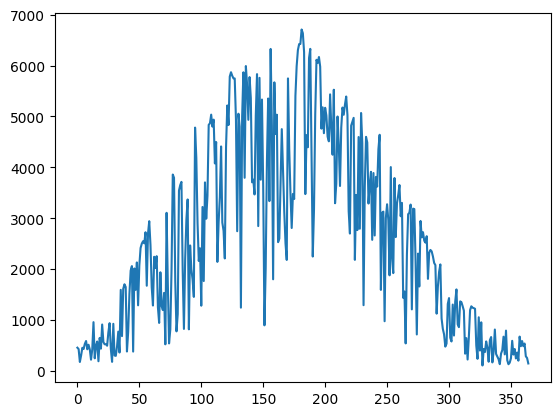

In [2]:
import matplotlib.pyplot as plt

plt.plot(total_array[0,5])
plt.show()

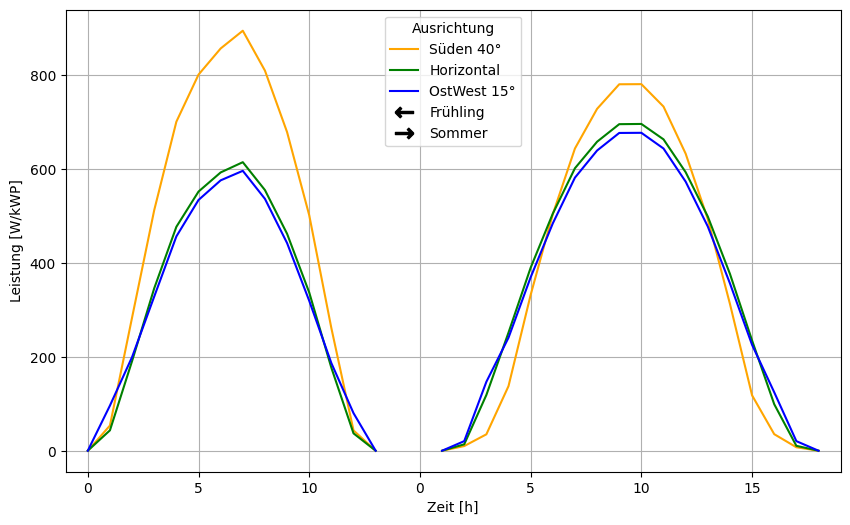

[datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0), datetime.datetime(2013, 3, 27, 0, 0)]
[datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013, 7, 8, 0, 0), datetime.datetime(2013

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Daten vorbereiten
day = np.array(day)
day2 = np.array(day2)

# Frühling
flat1 = day[0]
eastwest15_1 = (day[1] + day[2]) / 2
south40_1 = day[5]
x1 = np.arange(len(south40_1))  # x-Achse Frühling

# Sommer
flat2 = day2[0]
eastwest15_2 = (day2[1] + day2[2]) / 2
south40_2 = day2[5]
x2 = np.arange(len(south40_2)) + 16  # x-Achse Sommer verschoben

# Ein Plot
plt.figure(figsize=(10,6))

# Frühling - durchgezogene Linien
plt.plot(x1, south40_1, color='orange')
plt.plot(x1, flat1, color='green')
plt.plot(x1, eastwest15_1, color='blue')

# Sommer - gestrichelt
plt.plot(x2, south40_2, color='orange')
plt.plot(x2, flat2, color='green')
plt.plot(x2, eastwest15_2, color='blue')

plt.xlabel('Zeit [h]')
plt.ylabel('Leistung [W/kWP]')
plt.grid(True)

# x-Achse "rollen": Zeit >15 → Zeit-15
xticks = plt.xticks()[0]  # aktuelle Tick-Positionen
xticklabels = [(int(tick) - 15 if tick >= 15 else int(tick)) for tick in xticks]
plt.xticks(xticks, xticklabels)

# Legende anpassen: Punkte für Ausrichtung + Pfeile für Saison
legend_elements = [
    Line2D([0], [0], color='orange', label='Süden 40°'),
    Line2D([0], [0], color='green', label='Horizontal'),
    Line2D([0], [0], color='blue', label='OstWest 15°'),
    Line2D([0], [0], color='k', lw=0, marker=r'$\leftarrow$', markersize=13, label='Frühling'),
    Line2D([0], [0], color='k', lw=0, marker=r'$\rightarrow$', markersize=13, label='Sommer')
]

plt.legend(handles=legend_elements, title='Ausrichtung', ncol=1, loc='upper center')
plt.xlim(-1,34)
plt.savefig('Ausrichtung_Tagesgang.pdf')
plt.show()
print(time_day)
print(time_day2)

In [4]:
norm = np.mean(total_array)

flat = total_array[0]/11
eastwest15 = (total_array[1] + total_array[2])/2/11
eastwest35 = (total_array[3] + total_array[4])/2/11

print(np.mean(flat),np.mean(eastwest15), np.mean(eastwest35), 'Wh')

217.3459823389562 214.513316427035 205.65448262198575 Wh


In [5]:
print(f'{np.uint32(np.sum(np.sum(total_array,axis=2),axis=1)/1000/11)} kwh') 

[ 872  866  855  836  815 1049] kwh


In [6]:
ostwest = 866/2 + 855/2
diff = ostwest - 872
print(diff)
print(ostwest/872)

-11.5
0.9868119266055045


(365,)
(14,)


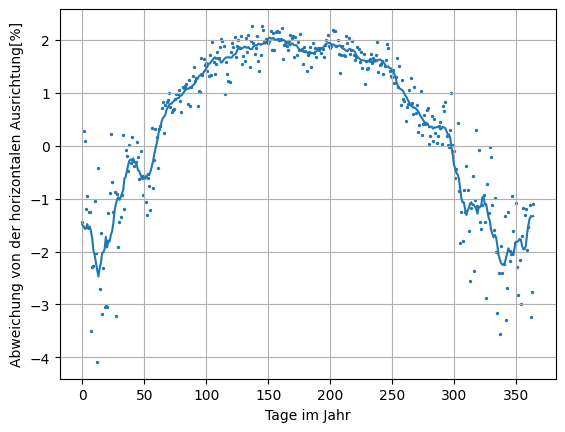

In [7]:
from scipy.ndimage import convolve1d

flat_mean = np.mean(flat,axis=0)
eastwest15_mean = np.mean(eastwest15,axis=0)

diff = flat_mean-eastwest15_mean
proz_diff = diff/np.where(flat_mean == 0,1e-12,flat_mean)*100
print(proz_diff.shape)
kernel = np.ones(14)/14
print(kernel.shape)
result = convolve1d(proz_diff, kernel, mode='wrap')
plt.scatter(np.arange(len(proz_diff)),proz_diff,s=2)
plt.plot(result)
plt.grid(True)
plt.ylabel('Abweichung von der horizontalen Ausrichtung[%]')
plt.xlabel('Tage im Jahr')
plt.savefig('Ausrichtung_Jahr.pdf')
plt.show()